<a href="https://colab.research.google.com/github/BigFoots625/IntroductionMachineLearningwithPython/blob/main/Chapter8__Wrap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Wrapping Up**
This final chapter transitions from the mathematical execution of algorithms to the holistic software engineering of machine learning systems. In a production environment, an algorithm is just one small gear in a massive machine.

Here, we will cover how to properly approach a business problem, deploy models into production, build custom scikit-learn components, and determine where to go next in your data journey.

In [1]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import warnings
warnings.filterwarnings("ignore")

### **Theoretical Explanation: Approaching a Machine Learning Problem**
Before you even open a Jupyter Notebook, you must thoroughly understand the business context.
1. **Humans in the Loop:** Who is the end-user? Is the model fully automated (like an algorithmic trader), or is it an assistant (like a medical tool flagging scans for a radiologist)? The level of human involvement drastically changes your acceptable false-positive/false-negative rates.
2. **Defining the Goal:** Business leaders rarely care about "Mean Squared Error" or "Accuracy." They care about increasing revenue, decreasing churn, or saving time. You must translate their high-level business goal into a mathematically optimizable machine learning metric.
3. **Data Representation:** Is the data you have truly representative of the data you will see in production? If you train a model to recognize street signs on data collected only in sunny weather, it will fail catastrophically during a rainstorm.

### **Theoretical Explanation: From Prototype to Production**
In a notebook, your goal is to prove a concept. In production, your goal is reliability, scalability, and maintainability.

Moving a model to production often involves entirely new challenges:
1. **Language Translation:** Data scientists usually prototype in Python, but the production backend might run on Java, C++, or Go. You may need to export the model (using formats like ONNX or PMML) or wrap it in a REST API.
2. **Latency vs. Accuracy:** A massive ensemble of deep neural networks might give you a 1% boost in accuracy, but if it takes 5 seconds to generate a prediction, it will ruin the user experience. Production engineering often requires trading slight accuracy for massive speed gains.
3. **Offline vs. Online Training:** Will your model be trained once and deployed as a static file (offline), or will it continuously update its weights as new data streams in (online)? Online learning is incredibly risky because a sudden influx of corrupted data can instantly break the live model.

### **Theoretical Explanation: Building Your Own Estimator**
In Chapter 6, we learned that EVERYTHING should go inside a `Pipeline`. But what if you have custom feature engineering logic (like a specific mathematical ratio) that isn't built into scikit-learn?

To use custom logic inside a `Pipeline` or `GridSearchCV`, you must create a Python class that strictly follows the scikit-learn API. A custom transformer must inherit from `BaseEstimator` and `TransformerMixin`, and it must implement three methods:
1.  `__init__`: Used exclusively to accept hyperparameters. It must NOT contain any data-dependent logic.
2.  `fit(X, y=None)`: Used to learn parameters from the training data (e.g., finding the mean). It must always return `self`.
3.  `transform(X)`: Used to apply the learned parameters to alter the data.

By inheriting from `BaseEstimator`, you automatically get `get_params()` and `set_params()`, allowing `GridSearchCV` to tune your custom code exactly like it tunes an SVM.

In [2]:
# Here is an example of building a fully compliant scikit-learn transformer
# This custom transformer clips extreme outliers in the dataset

class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, multiplier=3.0):
        # __init__ must only assign parameters to self. No data calculations!
        self.multiplier = multiplier

    def fit(self, X, y=None):
        # Learn the mean and standard deviation of the training data
        X = np.asarray(X)
        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)

        # fit must always return self
        return self

    def transform(self, X):
        # Apply the capping logic using the parameters learned in fit()
        X = np.asarray(X).copy()

        upper_limit = self.mean_ + (self.multiplier * self.std_)
        lower_limit = self.mean_ - (self.multiplier * self.std_)

        # Clip the values that fall outside the limits
        X = np.clip(X, lower_limit, upper_limit)
        return X

# Let's test our custom estimator in a standard pipeline
demo_data = np.array([[1], [2], [3], [100], [-50]])

# Create a pipeline using our custom Capper alongside a standard Scaler
custom_pipe = make_pipeline(OutlierCapper(multiplier=1.5), StandardScaler())

print("Original data:\n", demo_data.flatten())
print("\nData after Custom Capper + Scaler:\n", custom_pipe.fit_transform(demo_data).flatten())

Original data:
 [  1   2   3 100 -50]

Data after Custom Capper + Scaler:
 [-0.16386071 -0.14067546 -0.1174902   1.76833509 -1.34630871]


### **Testing Production Systtems**
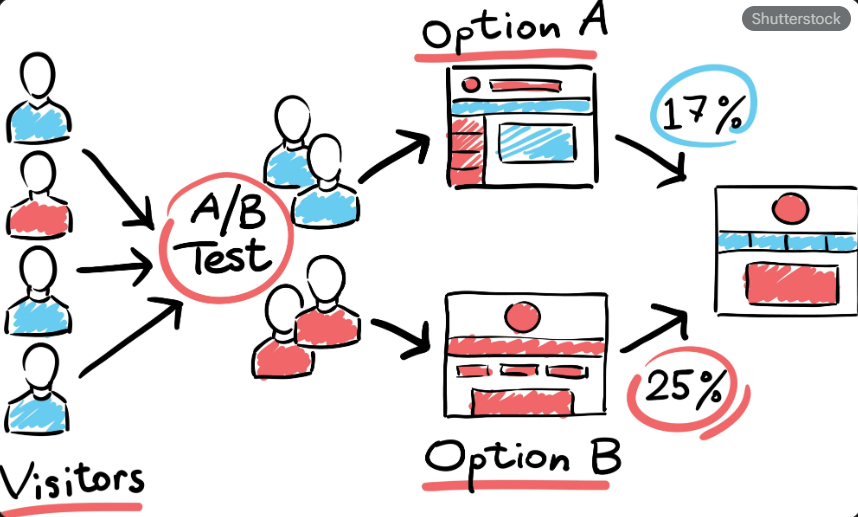

### **Theoretical Explanation: Testing Production Systems (A/B Testing)**
Even if your model achieves a perfect AUC score in cross-validation, you cannot guarantee it will actually improve business metrics until you test it live. The industry standard for this is **A/B Testing**.

1. You deploy the new machine learning model alongside the old system.
2. You randomly assign a small subset of live users (e.g., 10%) to experience the new model (Group B), while the rest experience the old system (Group A).
3. After a statistically significant period, you compare the true business metrics (like user engagement or total purchases) between the groups.

**Concept Drift:** Machine learning systems degrade over time because real-world data constantly shifts. The economy changes, user habits evolve, and sensors degrade. You must build monitoring dashboards to track prediction distributions and trigger model retraining when the real-world data drifts too far from the original training data.

### **Theoretical Explanation: Where to Go from Here**
This book provided the practical foundation, but the field is vast. The authors recommend the following areas for further exploration:

1. **Theory:** Reading advanced texts like *The Elements of Statistical Learning* to understand the rigorous calculus and linear algebra driving these algorithms.
2. **Deep Learning:** Exploring neural networks further using specialized frameworks like TensorFlow or PyTorch, which dominate computer vision, audio processing, and advanced NLP.
3. **Big Data:** Scikit-learn requires all data to fit entirely in your computer's RAM. If you are dealing with terabytes of data, you need to explore distributed computing frameworks like Apache Spark (and its MLlib library).
4. **Other Modalities:** Exploring specific sub-fields like Recommender Systems, Time Series Forecasting, and Reinforcement Learning.

### **Chapter 8 Summary**
* **Objective:** We zoomed out to view the entire lifecycle of a machine learning project, from initial scoping to live deployment.
* **Key Concepts Covered:**
    * **Problem Definition:** Ensuring your mathematical goals align directly with your business goals.
    * **Productionization:** Balancing the trade-offs between complex accuracy, prediction latency, and system stability.
    * **Custom Estimators:** Leveraging `BaseEstimator` and `TransformerMixin` to force custom engineering logic to play perfectly with scikit-learn's API.
    * **Live Evaluation:** Using A/B testing and active monitoring to combat concept drift and prove real-world value.
* **Takeaway:** A successful data practitioner does not just run `.fit()` and `.predict()`. They architect end-to-end systems that are robust, testable, and deeply integrated into the business.